<a href="https://colab.research.google.com/github/marescost4/Mariane-David-Fillipy/blob/main/semana02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação de bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Explicação das Variáveis

O DataFrame `dados` contém as seguintes variáveis:

*   **`ambiente`**: Representa o tipo de ambiente onde a coleta foi realizada (mata, cerrado, campo). É uma variável **qualitativa nominal**, pois as categorias não possuem uma ordem natural.

*   **`nivel_impacto`**: Indica o nível de impacto ambiental observado (baixo, moderado, alto). É uma variável **qualitativa ordinal**, pois as categorias possuem uma ordem intrínseca.

*   **`riqueza_especies`**: O número de diferentes espécies encontradas na parcela. É uma variável **quantitativa discreta**, pois resulta de uma contagem e assume valores inteiros.

*   **`cobertura_vegetal_pct`**: A porcentagem de cobertura vegetal do solo na parcela. É uma variável **quantitativa contínua**, pois pode assumir qualquer valor dentro de um intervalo (de 0 a 100).

# Conjunto de dados biológicos

In [2]:

dados = pd.DataFrame({
    "ambiente": [
        "mata", "cerrado", "campo", "mata", "cerrado",
        "campo", "mata", "cerrado", "mata", "campo",
        "cerrado", "mata", "campo", "cerrado", "mata",
        "campo", "cerrado", "mata", "campo", "cerrado"
    ],  # nominal
    "nivel_impacto": [
        "baixo", "moderado", "alto", "baixo", "moderado",
        "alto", "baixo", "moderado", "baixo", "alto",
        "moderado", "baixo", "alto", "moderado", "baixo",
        "alto", "moderado", "baixo", "alto", "moderado"
    ],  # ordinal
    "riqueza_especies": [
        18, 12, 7, 20, 14, 6, 22, 13, 19, 8,
        15, 21, 5, 11, 23, 7, 14, 20, 6, 12
    ],  # discreta
    "cobertura_vegetal_pct": [
        88.5, 64.2, 31.8, 91.0, 68.7, 28.4, 94.3, 61.5, 86.9, 35.2,
        70.1, 92.4, 24.8, 58.9, 96.0, 32.7, 66.3, 89.7, 27.5, 63.8
    ]  # contínua
})

dados.head()

,ambiente,nivel_impacto,riqueza_especies,cobertura_vegetal_pct
0,mata,baixo,18,88.5
1,cerrado,moderado,12,64.2
2,campo,alto,7,31.8
3,mata,baixo,20,91.0
4,cerrado,moderado,14,68.7


# Tabelas de frequências

In [3]:
# 3. Frequência absoluta da variável nominal: ambiente
freq_ambiente = dados["ambiente"].value_counts()
freq_ambiente

,count
ambiente,
mata,7
cerrado,7
campo,6


In [9]:
# 4. Frequência relativa (%) da variável nominal: ambiente
freq_ambiente_rel = dados["ambiente"].value_counts(normalize=True) *100 #true = freq relativa False = Freq normal
freq_ambiente_rel
#freq_ambiente_rel.round(1) # Round = quantas casas decimal depois da virgula

,proportion
ambiente,
mata,35.0
cerrado,35.0
campo,30.0


In [ ]:
# 5. Frequência da variável ordinal: nível de impacto
freq_impacto = dados["nivel_impacto"].value_counts()
freq_impacto

,count
nivel_impacto,
baixo,7
moderado,7
alto,6


In [12]:
# 6. Frequência da variável discreta: riqueza de espécies
freq_riqueza = dados["riqueza_especies"].value_counts().sort_index() #sort_index = ordenar de menor pro maior
freq_riqueza

,count
riqueza_especies,
5,1
6,2
7,2
8,1
11,1
12,2
13,1
14,2
15,1


In [15]:
# 7. Classes para a variável contínua: cobertura vegetal
print("Exemplo de classes com intervalo fechado à esquerda:")

classes_cobertura = pd.cut(
    dados["cobertura_vegetal_pct"],
    bins=[20, 40, 60, 80, 100], # Porcentagem
    labels=["[20-40)", "[40-60)", "[60-80)", "[80-100)"],
    right=False
)

freq_cobertura = classes_cobertura.value_counts().sort_index()
freq_cobertura

Exemplo de classes com intervalo fechado à esquerda:


,count
cobertura_vegetal_pct,
[20-40),6
[40-60),1
[60-80),6
[80-100),7


# Gráficos

## Gráfico de barras

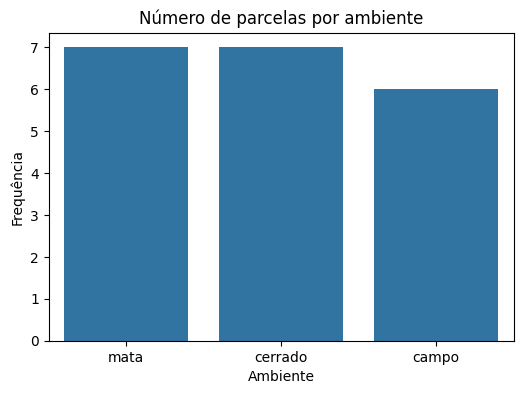

In [16]:

plt.figure(figsize=(6, 4))
sns.countplot(data=dados, x="ambiente")
plt.title("Número de parcelas por ambiente")
plt.xlabel("Ambiente")
plt.ylabel("Frequência")
plt.show()

## Gráfico de pizza ou setores

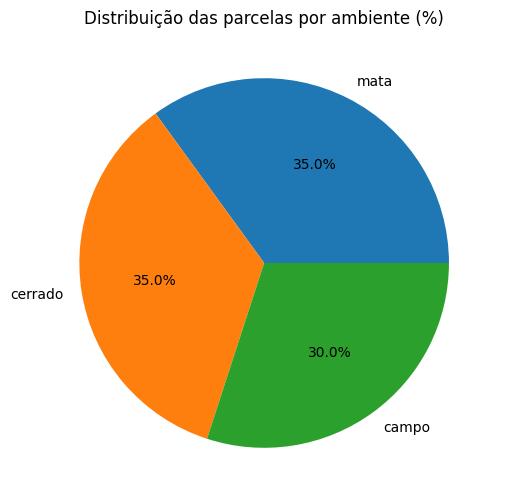

In [17]:
freq_ambiente = dados["ambiente"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    freq_ambiente,
    labels=freq_ambiente.index,
    autopct="%.1f%%"
)
plt.title("Distribuição das parcelas por ambiente (%)")
plt.show()

## Histograma

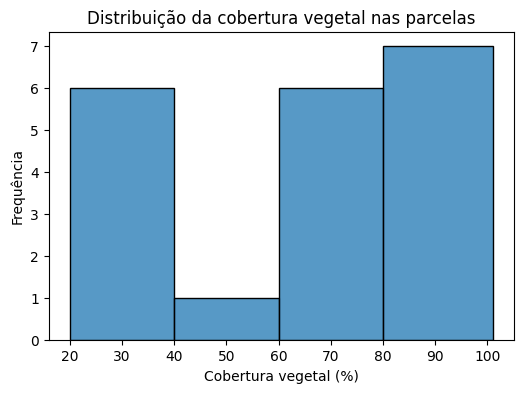

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(
    data=dados, #Histograma
    x="cobertura_vegetal_pct",
    bins=[20, 40, 60, 80, 101],
    kde=False
)
plt.title("Distribuição da cobertura vegetal nas parcelas")
plt.xlabel("Cobertura vegetal (%)")
plt.ylabel("Frequência") #frequencia absoluta
plt.show()

## Boxplot ou gráfico de caixas-e-bigodes

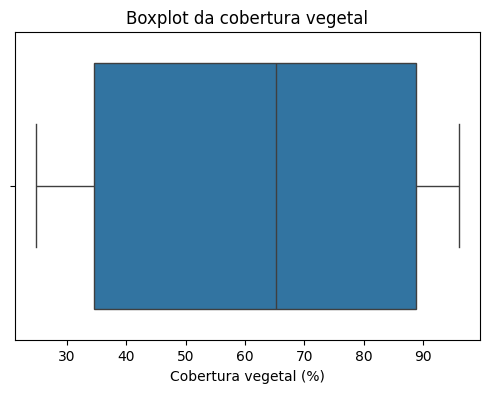

In [19]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=dados, x="cobertura_vegetal_pct")
plt.title("Boxplot da cobertura vegetal")
plt.xlabel("Cobertura vegetal (%)")
plt.show()

## Gráfico de dispersão

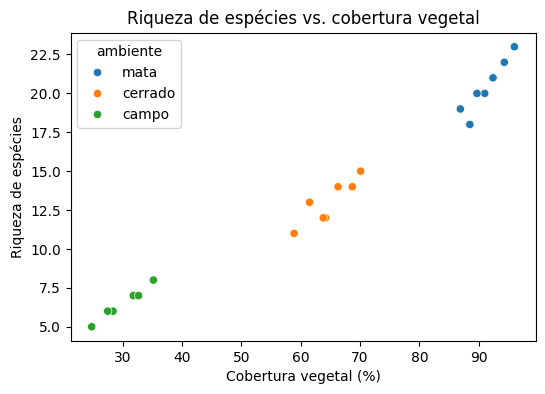

In [20]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=dados,
    x="cobertura_vegetal_pct",
    y="riqueza_especies",
    hue="ambiente"
)
plt.title("Riqueza de espécies vs. cobertura vegetal")
plt.xlabel("Cobertura vegetal (%)")
plt.ylabel("Riqueza de espécies")
plt.show()

## Gráfico de dispersão interativo com Plotly

In [21]:
fig = px.scatter(
    dados,
    x="cobertura_vegetal_pct",
    y="riqueza_especies",
    color="ambiente",
    title="Riqueza de espécies vs. cobertura vegetal (interativo)"
)
fig.show()